# Sleep Health Prediction

In this notebook, I am going to analyze a sleep health dataset and build a prediction model for `sleep_quality_score`. I will start by loading the dataset and checking its structure, then explore the data using summary statistics and visualizations. After that, I will build a Linear Regression model using the numeric features, compare the predicted sleep quality scores with the actual values, and evaluate the model using the R-squared score.


### Importing the required libraries

In this cell, I imported the main libraries needed for the project. Pandas and NumPy are used for data handling, Matplotlib and Seaborn are used for visualizations, and Scikit-learn is used for splitting the data, building the Linear Regression model, and checking the model performance.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error,mean_absolute_error


### Loading the dataset

In this cell, I loaded the `sleep_health_dataset.csv` file into a Pandas DataFrame named `sleep_health_df` so that I can inspect, analyze, and model the data.


In [2]:
sleep_health_df = pd.read_csv("sleep_health_dataset.csv")

### Checking the dataset size

In this cell, I checked the shape of the dataset to see how many rows and columns it contains.


In [3]:
sleep_health_df.shape

(100000, 32)

### Viewing the column names

In this cell, I displayed all column names in the dataset to understand what features are available for analysis and prediction.


In [4]:
sleep_health_df.columns

Index(['person_id', 'age', 'gender', 'occupation', 'bmi', 'country',
       'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage',
       'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'chronotype', 'mental_health_condition',
       'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work',
       'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season',
       'day_type', 'cognitive_performance_score', 'sleep_disorder_risk',
       'felt_rested'],
      dtype='str')

### Viewing the first records

In this cell, I displayed the first 10 rows of the dataset to get an initial look at the values and overall structure of the data.


In [5]:
sleep_health_df.head(10)

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0
5,6,23,Female,Driver,25.5,Brazil,8.16,5.7,17.3,20.1,...,71,1,0,22.7,0.70,Summer,Weekend,49.9,Mild,1
6,7,20,Female,Software Engineer,18.2,Netherlands,7.27,5.1,17.5,18.8,...,79,0,0,17.6,0.73,Spring,Weekend,57.9,Mild,1
7,8,48,Female,Freelancer,31.5,UK,8.04,6.5,25.3,22.3,...,60,1,0,21.6,0.47,Winter,Weekend,92.0,Mild,0
8,9,37,Male,Manager,29.9,USA,6.04,5.4,18.9,15.7,...,74,0,0,17.8,1.80,Autumn,Weekend,53.6,Mild,0
9,10,41,Female,Nurse,34.8,USA,6.22,4.9,21.4,15.5,...,80,1,0,24.4,1.51,Autumn,Weekday,67.8,Mild,1


### Viewing the last records

In this cell, I displayed the last 10 rows of the dataset to check how the data looks toward the end of the file.


In [6]:
sleep_health_df.tail(10)

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
99990,99991,44,Female,Homemaker,24.5,India,6.84,6.0,18.0,19.3,...,67,0,0,20.0,1.77,Winter,Weekend,72.2,Healthy,1
99991,99992,22,Female,Driver,24.5,Brazil,7.12,6.8,25.9,22.1,...,67,1,0,26.0,0.41,Winter,Weekday,85.6,Healthy,0
99992,99993,53,Male,Teacher,27.3,Mexico,5.84,5.8,25.2,14.6,...,67,0,0,19.1,1.28,Winter,Weekday,64.2,Healthy,0
99993,99994,31,Male,Software Engineer,28.9,Brazil,7.92,5.1,18.7,18.1,...,68,0,0,17.7,2.19,Spring,Weekday,47.5,Mild,1
99994,99995,47,Male,Homemaker,28.6,India,5.97,4.6,13.5,20.0,...,66,0,0,19.9,2.36,Winter,Weekday,56.2,Mild,0
99995,99996,44,Female,Nurse,25.9,USA,6.77,6.3,26.8,24.6,...,72,1,0,19.1,1.93,Spring,Weekend,89.4,Healthy,1
99996,99997,44,Female,Manager,30.2,India,4.90,4.1,21.6,22.3,...,80,1,0,18.6,1.44,Spring,Weekday,40.5,Mild,0
99997,99998,39,Male,Manager,29.2,Brazil,5.94,5.1,21.4,14.3,...,74,1,0,19.4,0.62,Spring,Weekday,64.8,Healthy,1
99998,99999,33,Female,Nurse,27.3,India,5.27,3.0,21.9,23.6,...,68,1,0,20.6,2.32,Winter,Weekend,40.8,Mild,0
99999,100000,30,Male,Sales,24.3,USA,6.33,4.7,14.5,25.3,...,48,0,0,21.1,-0.12,Autumn,Weekday,54.3,Mild,0


### Viewing random records

In this cell, I displayed 5 random rows from the dataset. This helps me inspect different examples instead of only looking at the beginning or end of the data.


In [7]:
sleep_health_df.sample(5)

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
78370,78371,25,Female,Retired,21.1,Japan,7.55,6.3,25.6,19.2,...,61,0,0,17.7,0.62,Winter,Weekday,82.1,Healthy,1
87538,87539,33,Male,Driver,25.7,Mexico,5.71,4.8,20.7,23.9,...,58,1,0,18.4,1.84,Summer,Weekend,63.9,Healthy,1
95154,95155,64,Male,Doctor,27.8,Germany,5.86,2.5,27.9,20.1,...,68,0,1,18.1,1.28,Winter,Weekend,56.6,Moderate,0
39757,39758,39,Male,Homemaker,24.6,Japan,6.34,6.4,21.6,23.3,...,59,1,0,23.0,1.91,Summer,Weekday,71.8,Healthy,0
89652,89653,39,Female,Manager,22.7,India,6.65,5.2,17.2,18.8,...,59,1,0,17.8,2.17,Winter,Weekend,59.0,Healthy,1


### Summary statistics

In this cell, I generated descriptive statistics for the numeric columns, such as count, mean, standard deviation, minimum, and maximum values. This helps me understand the distribution and range of the numerical data.


In [8]:
sleep_health_df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


### Dataset information

In this cell, I checked the data types, non-null counts, and memory usage of each column. This helps identify missing values and understand which columns are numeric or categorical.


In [9]:
sleep_health_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  str    
 3   occupation                   100000 non-null  str    
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  str    
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  alcohol_uni

### Counting records by country

In this cell, I counted how many records belong to each country. This helps me understand the distribution of the dataset across countries.


In [10]:
sleep_health_df.country.value_counts()

country
USA            20050
India          17840
Japan           8089
UK              8024
Brazil          7146
Germany         6026
Canada          4995
France          4982
Australia       4948
Italy           4018
South Korea     3971
Mexico          3888
Netherlands     3040
Spain           2011
Sweden           972
Name: count, dtype: int64

### Checking the country count total

In this cell, I referenced the total count from the country value counts. To calculate and display the total number properly, this method should be called as `.sum()`.


In [11]:
sleep_health_df.country.value_counts().sum

<bound method Series.sum of country
USA            20050
India          17840
Japan           8089
UK              8024
Brazil          7146
Germany         6026
Canada          4995
France          4982
Australia       4948
Italy           4018
South Korea     3971
Mexico          3888
Netherlands     3040
Spain           2011
Sweden           972
Name: count, dtype: int64>

### Creating a prediction column

In this cell, I created a new column named `predicted_sleep_quality_score` and initialized it with 0. Later, this column is used to store the model's predicted sleep quality scores.


In [12]:
sleep_health_df['predicted_sleep_quality_score']= 0

### Confirming the updated columns

In this cell, I displayed the column names again to confirm that the new `predicted_sleep_quality_score` column was added to the dataset.


In [13]:
sleep_health_df.columns

Index(['person_id', 'age', 'gender', 'occupation', 'bmi', 'country',
       'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage',
       'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'chronotype', 'mental_health_condition',
       'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work',
       'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season',
       'day_type', 'cognitive_performance_score', 'sleep_disorder_risk',
       'felt_rested', 'predicted_sleep_quality_score'],
      dtype='str')

### Exploratory Data Analysis (EDA)

In this section, I explore the dataset visually to understand relationships between different features and the target variable `sleep_quality_score`. This includes scatter plots, line plots, box plots, and a correlation heatmap.


### Sleep duration and sleep quality

In this cell, I created a scatter plot to compare `sleep_duration_hrs` with `sleep_quality_score`. This helps show whether sleep duration has a visible relationship with sleep quality.


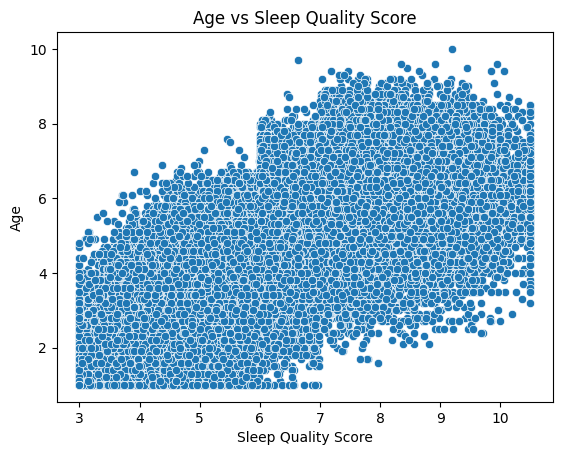

In [14]:
sns.scatterplot(
    x='sleep_duration_hrs',
    y='sleep_quality_score',
    data=sleep_health_df
)

plt.xlabel('Sleep Quality Score')
plt.ylabel('Age')
plt.title('Age vs Sleep Quality Score')
plt.show()
plt.show()

### Stress score and sleep quality

In this cell, I created a scatter plot to compare `stress_score` with `sleep_quality_score`. This helps me observe whether higher stress levels are related to changes in sleep quality.


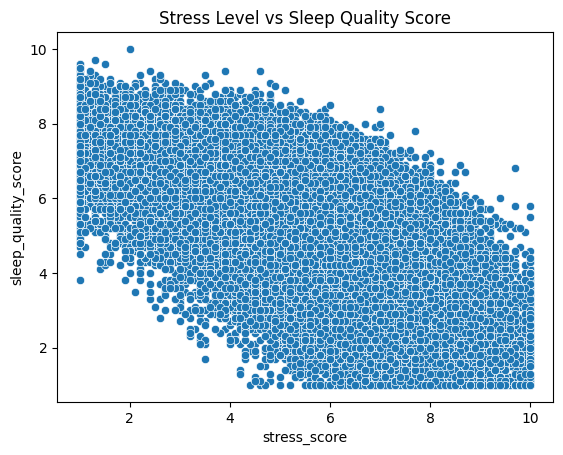

In [15]:
sns.scatterplot(
    x='stress_score',
    y='sleep_quality_score',
    data=sleep_health_df
)
plt.title('Stress Level vs Sleep Quality Score')
plt.show()

### Occupation and sleep quality

In this cell, I plotted `occupation` against `sleep_quality_score` to explore whether sleep quality varies across different occupations.


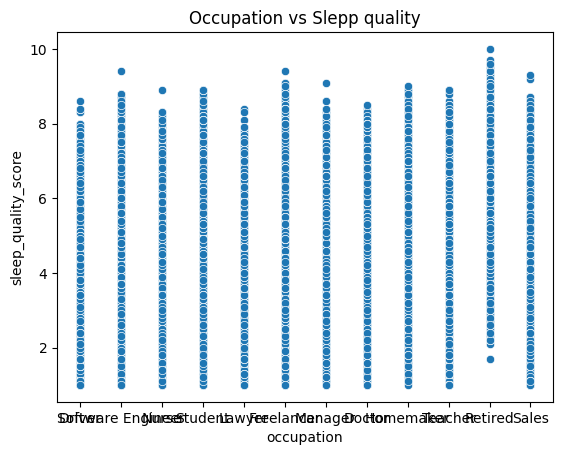

In [16]:
sns.scatterplot(
    x='occupation',
    y='sleep_quality_score',
    data=sleep_health_df
)
plt.title('Occupation vs Slepp quality')
plt.show()

### Distribution of sleep quality score

In this cell, I created a histogram of `sleep_quality_score` to see how the target variable is distributed across the dataset.


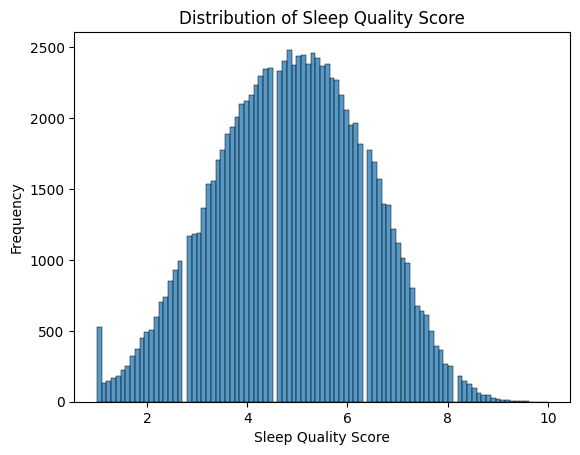

In [17]:
sns.histplot(data=sleep_health_df['sleep_quality_score'])
plt.title('Distribution of Sleep Quality Score')
plt.xlabel('Sleep Quality Score')
plt.ylabel('Frequency')
plt.show()

### Insights from the plots so far

From the plots above, I look at how `sleep_duration_hrs`, `stress_score`, and `occupation` relate to `sleep_quality_score`, and at the overall distribution of the target variable. These visuals help me decide which features might be useful for the prediction model.


### Age and sleep quality trend

In this cell, I used a line-style relational plot to compare `sleep_quality_score` with `age`. This helps explore whether sleep quality changes across different ages.


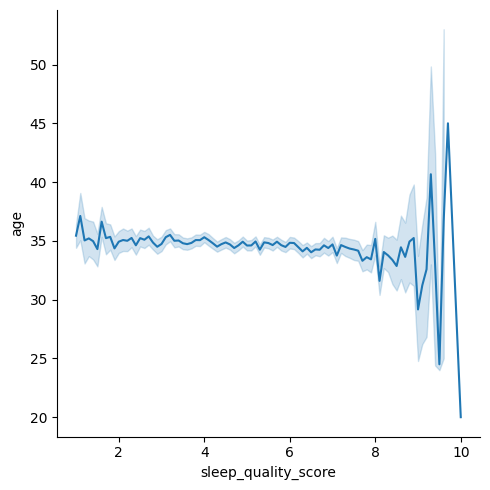

In [18]:
sns.relplot(data=sleep_health_df,x='sleep_quality_score',y='age',kind='line')
plt.xlabel='Sleep Quality Score'
plt.ylabel='Age'
plt.title='Age vs Sleep Quality Score'
plt.show()

### Sleep quality by country

In this cell, I used a line plot to compare sleep quality scores across countries, with country also shown using color.


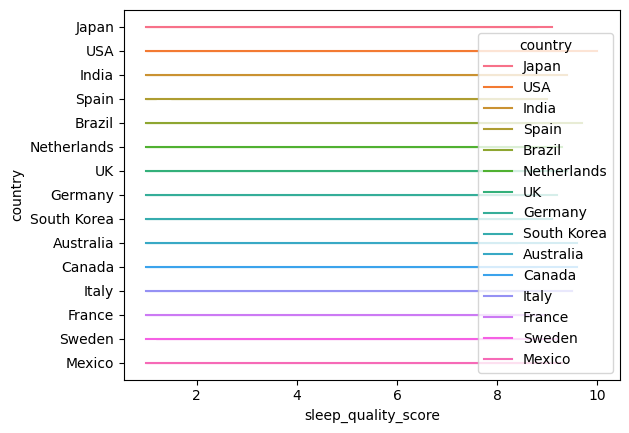

In [19]:
sns.lineplot(data=sleep_health_df,x='sleep_quality_score',y='country',hue='country',legend='brief')
plt.show()

### Country-wise sleep quality spread

In this cell, I created a box plot to compare the distribution of `sleep_quality_score` for each country. This helps show the median, spread, and possible outliers by country.


<Axes: xlabel='sleep_quality_score', ylabel='country'>

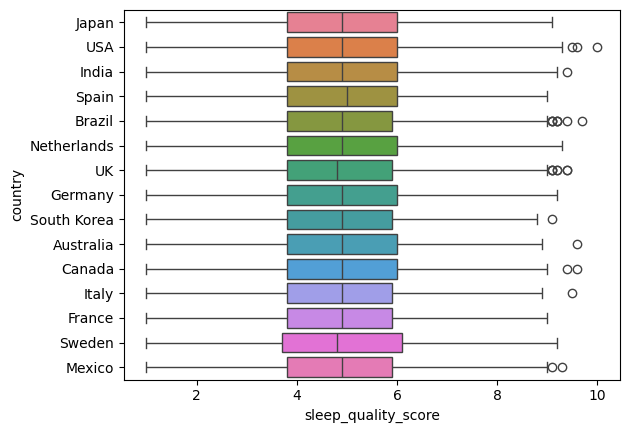

In [20]:

sns.boxplot(data=sleep_health_df,x='sleep_quality_score',y='country',hue='country')


### Sleep quality by gender

In this cell, I plotted sleep quality scores by gender to explore whether sleep quality differs across gender groups.


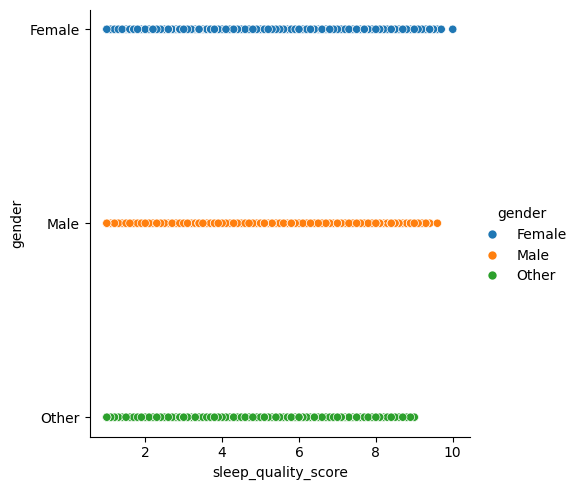

In [21]:
sns.relplot(data=sleep_health_df,x='sleep_quality_score',y='gender',hue='gender')

### Correlation heatmap

In this cell, I created a heatmap of the correlations between numeric columns. This helps identify which numeric features have stronger positive or negative relationships with each other and with sleep quality.


<Axes: >

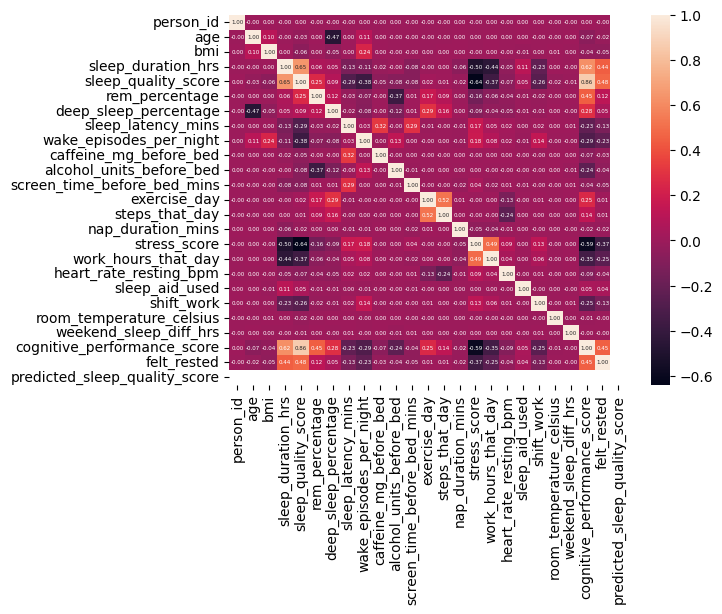

In [22]:
## heatmap
plt.Figure(figsize=(20,20))
sns.heatmap(data=sleep_health_df.corr(numeric_only=True),annot=True,fmt='.2f',annot_kws={'size':4
                                                                                         })

### Label Encoding

In this section, I convert the categorical (text) columns in the dataset into numeric codes using `LabelEncoder`, since machine learning models in Scikit-learn require numeric input.


In [23]:
le = LabelEncoder()

### Applying label encoding to text columns

In this cell, I loop through the columns with text/string data type and apply the `LabelEncoder` to convert each one into numeric codes, replacing the original text values in `sleep_health_df`. Note: `select_dtypes(include=['str'])` may not reliably catch object/text columns in pandas — `include=['object']` is the more common way to select text columns, so it's worth checking that this loop is actually catching all the categorical columns.


In [24]:
for col in sleep_health_df.select_dtypes(include=['str']):
    print(col)
    sleep_health_df[col]=le.fit_transform(sleep_health_df[col])

gender
occupation
country
chronotype
mental_health_condition
season
day_type
sleep_disorder_risk


## Linear Regression Model


### Model Building

In this section, I prepare the features and target, split the data into training and testing sets, and build a Linear Regression model to predict `sleep_quality_score`.


### Separating features and target

In this cell, I selected the numeric columns as input features and removed `sleep_quality_score` from them. I then stored `sleep_quality_score` separately as the target variable that the model will learn to predict.


In [25]:
x=sleep_health_df.drop('sleep_quality_score',axis= 1)
y=sleep_health_df['sleep_quality_score']

### Checking feature and target shapes

In this cell, I printed the shapes of `x` and `y` to confirm that the feature data and target data have matching row counts before training the model.


In [26]:
print(x.shape)
print(y.shape)

(100000, 32)
(100000,)


### Splitting the dataset

In this cell, I split the data into training and testing sets. I used 80% of the data for training and 20% for testing, with a fixed random state so the split can be reproduced.


In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=123)

### Previewing the training features

In this cell, I displayed `x_train` to check the feature values that will be used to train the model.


In [28]:
x_train

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,rem_percentage,deep_sleep_percentage,sleep_latency_mins,...,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested,predicted_sleep_quality_score
22302,22303,33,0,4,21.6,4,6.46,14.5,19.3,23,...,1,0,15.0,-0.52,3,1,38.6,1,1,0
49609,49610,27,1,0,22.5,5,4.08,16.3,21.5,9,...,0,0,19.3,1.04,2,0,8.6,2,1,0
89251,89252,24,1,6,25.9,9,5.29,28.0,21.8,28,...,0,0,27.2,1.95,0,0,56.0,2,0,0
96385,96386,31,1,8,21.8,4,7.43,22.2,17.1,17,...,0,0,19.0,1.66,3,1,88.5,0,1,0
17569,17570,44,0,1,26.1,5,3.41,22.0,17.8,28,...,0,0,18.0,2.07,3,0,32.4,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63206,63207,21,0,9,30.1,14,7.15,21.9,30.0,26,...,1,0,17.5,0.13,2,0,95.7,0,1,0
61404,61405,28,0,9,32.4,1,6.22,18.4,22.3,23,...,0,0,19.7,1.50,3,0,77.9,0,0,0
17730,17731,33,1,0,16.9,2,5.49,20.6,28.1,9,...,0,0,19.6,1.51,1,0,58.9,0,0,0
28030,28031,68,0,8,27.2,14,7.39,18.1,11.0,25,...,1,0,22.4,1.24,3,1,68.6,0,1,0


### Checking the training set size

In this cell, I printed the shapes of the training features and training target to confirm the training data was split correctly.


In [29]:
print(x_train.shape)
print(y_train.shape)

(80000, 32)
(80000,)


### Checking the testing set size

In this cell, I printed the shape of the test features and the size of the test target to confirm the testing data was split correctly.


In [30]:
print(x_test.shape)
print(y_test.size)

(20000, 32)
20000


### Creating the Linear Regression model

In this cell, I created a Linear Regression model object. This model will learn the relationship between the numeric features and the sleep quality score.


In [31]:
simple_linear_model=LinearRegression()

### Training the model

In this cell, I trained the Linear Regression model using the training features and training target values.


In [32]:
simple_linear_model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Viewing model coefficients

In this cell, I displayed the model coefficients. These values show how each input feature contributes to the predicted sleep quality score.


In [33]:
simple_linear_model.coef_

array([-5.17808339e-08, -5.41713779e-04,  1.06909101e-04, -4.12761018e-03,
       -1.89260573e-03, -2.84788794e-04,  1.37267828e-01, -2.58125373e-02,
       -3.42777271e-02, -1.76090833e-02, -1.15269979e-01,  5.80887352e-04,
        1.26358598e-01, -1.32848034e-04, -4.19202063e-01,  2.60705398e-07,
        8.20741986e-05, -8.87083386e-02, -4.68580891e-03,  1.27394657e-03,
        1.09379550e-01, -1.69385801e-04, -4.07852733e-03, -6.21858981e-02,
       -8.55894982e-03, -2.52687629e-03, -2.86405675e-03, -1.22414516e-01,
        5.25022599e-02,  8.18019719e-02,  8.55788987e-02,  0.00000000e+00])

### Viewing the model intercept

In this cell, I displayed the model intercept, which is the baseline prediction value used by the Linear Regression equation.


In [34]:
simple_linear_model.intercept_

np.float64(3.4621314658220026)

### Making predictions on test data

In this cell, I used the trained model to predict sleep quality scores for the test set and stored the predictions in `y_pred`.


In [35]:
y_pred = simple_linear_model.predict(x_test)
y_pred

array([6.90724578, 5.83394123, 5.82619104, ..., 3.89433379, 6.832058  ,
       2.82664188], shape=(20000,))

### Comparing predicted and actual values

In this cell, I printed the first 10 predicted values and compared them with the first 10 actual test values. This gives a quick check of how close the predictions are to the real scores.


In [36]:
print(y_pred[:10])
y_test[:10]

[6.90724578 5.83394123 5.82619104 6.52668968 4.86780589 3.88166607
 7.6020274  4.65342753 6.32724457 5.46952895]


42083    6.8
71825    5.6
99535    5.4
47879    6.7
36734    4.9
48636    4.4
59566    7.5
44826    4.9
51584    5.6
4368     4.8
Name: sleep_quality_score, dtype: float64

### Evaluating the model

In this cell, I calculated the R-squared score on the test data. This score shows how much of the variation in sleep quality score is explained by the model.


In [37]:
r2_score(y_test,y_pred)

0.8609693449400966

### Saving predictions in the dataset

In this cell, I used the trained model to predict sleep quality scores for the full numeric dataset and saved those predictions in the `predicted_sleep_quality_score` column.


In [38]:
sleep_health_df['predicted_sleep_quality_score'] = simple_linear_model.predict(x)

### Viewing the saved predictions

In this cell, I displayed the `predicted_sleep_quality_score` column to check the predicted values that were added to the dataset.


In [39]:
sleep_health_df['predicted_sleep_quality_score']

0        5.924186
1        7.073626
2        1.132838
3        5.341302
4        3.274103
           ...   
99995    5.953576
99996    4.134862
99997    5.798830
99998    3.440339
99999    4.778477
Name: predicted_sleep_quality_score, Length: 100000, dtype: float64

### Comparing train and test performance

In this cell, I printed the model score for both the training set and the testing set. Comparing these scores helps check whether the model performs consistently on unseen data.


In [40]:
print("Train R²:", simple_linear_model.score(x_train, y_train))
print("Test R² :", simple_linear_model.score(x_test, y_test))

Train R²: 0.8588107755271961
Test R² : 0.8609693449400966


## Random Forest Regressor Model

In this section, I build a Random Forest Regressor as an alternative to Linear Regression, train it on the same data, and evaluate its performance on the test set.


### Preparing features and target for Random Forest

In this cell, I create `X` (all columns except `sleep_quality_score`) as the features and `Y` as the target variable, in preparation for training the Random Forest model.


In [41]:
X = sleep_health_df.drop(columns=["sleep_quality_score",'predicted_sleep_quality_score'])
Y = sleep_health_df["sleep_quality_score"]

### Splitting the data for Random Forest

In this cell, I split the data into training and testing sets using an 80/20 split. Note: this split reuses the lowercase `y` from the earlier Linear Regression step rather than the newly created `Y`, so `Y_train`/`Y_test` actually contain the same target values as before — this is worth double-checking since it could be a copy-paste leftover.


In [42]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

### Creating and training the Random Forest model

In this cell, I create a `RandomForestRegressor` with 100 trees and train it on the training data.


In [43]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Making predictions with the Random Forest model

In this cell, I use the trained Random Forest model to predict `sleep_quality_score` values for the test set.


In [44]:
Y_pred = rf.predict(X_test)
Y_pred

array([3.854, 2.425, 4.848, ..., 4.911, 5.155, 5.125], shape=(20000,))

### Previewing Random Forest predictions

In this cell, I print the first 10 predicted values from the Random Forest model.


In [45]:
print(Y_pred[:10])

[3.854 2.425 4.848 2.768 3.715 5.374 5.552 2.994 6.062 5.006]


### Comparing actual vs predicted values (Random Forest)

In this cell, I build a small DataFrame that places the actual and predicted values side by side, then print the first 10 rows to visually compare how close the predictions are.


In [46]:
comparison = pd.DataFrame({
    'Actual': Y_test,
    'Predicted': Y_pred
})

print(comparison.head(10))

       Actual  Predicted
75721     3.6      3.854
80184     1.2      2.425
19864     5.6      4.848
76699     2.7      2.768
92991     3.8      3.715
76434     4.9      5.374
84004     5.8      5.552
80917     2.5      2.994
60767     6.6      6.062
50074     4.5      5.006


### Evaluating the Random Forest model

In this cell, I calculate the R-squared score and the Mean Absolute Error (MAE) for the Random Forest model on the test set. These metrics show how well the model explains the variation in sleep quality and how far off the predictions are on average.


In [47]:
print("R²:", r2_score(Y_test, Y_pred))
print("MAE:", mean_absolute_error(Y_test, Y_pred))

R²: 0.8691219139936437
MAE: 0.4371780500000001


### Decision Tree Model

In this section, I build a Decision Tree Regressor as another alternative model, train it on the same data, and compare its performance with the previous models.


### Creating and training the Decision Tree model

In this cell, I create a `DecisionTreeRegressor` and train it on the same training data used for the Random Forest model.


In [48]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, Y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

### Making predictions with the Decision Tree model

In this cell, I use the trained Decision Tree model to predict `sleep_quality_score` values for the test set.


In [49]:
Y_pred_dt = dt.predict(X_test)
Y_pred_dt

array([2.7, 2.2, 4.3, ..., 4.2, 5.2, 4.8], shape=(20000,))

### Comparing actual vs predicted values (Decision Tree)

In this cell, I build a DataFrame comparing the actual and predicted values from the Decision Tree model and print the first 10 rows.


In [50]:
comparison_dt = pd.DataFrame({
    'Actual': Y_test,
    'Predicted': Y_pred_dt
})

print(comparison_dt.head(10))

       Actual  Predicted
75721     3.6        2.7
80184     1.2        2.2
19864     5.6        4.3
76699     2.7        2.8
92991     3.8        3.2
76434     4.9        5.6
84004     5.8        5.6
80917     2.5        3.2
60767     6.6        6.2
50074     4.5        4.7


### Evaluating the Decision Tree model

In this cell, I calculate the R-squared score and Mean Absolute Error (MAE) for the Decision Tree model on the test set.


In [51]:
print("R²:", r2_score(Y_test, Y_pred_dt))
print("MAE:", mean_absolute_error(Y_test, Y_pred_dt))

R²: 0.71681372174122
MAE: 0.6423650000000001


### Comparing Decision Tree train vs test performance

In this cell, I print the R-squared score for both the training set and the testing set for the Decision Tree model. Comparing these two scores helps check whether the model is overfitting (performing much better on training data than on test data).


In [52]:
train_r2 = dt.score(X_train, Y_train)
test_r2 = dt.score(X_test, Y_test)

print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train R²: 1.0
Test R²: 0.71681372174122
